# Notebook to validate blinding data:

In [1]:
import logging

import os
from pathlib import Path
import functools

import numpy as np
import matplotlib.pyplot as plt

logger = logging.getLogger('FIT PNG')

# remove warning on my mac -> deactivate on NERSC.
os.environ['OMPI_MCA_btl'] = 'self,tcp'  # deactivate shmem

# disable jax warning:
for logger_name in ['jax._src.xla_bridge', 'jax._src.distributed', 'jax._src.interpreters.pxla', 'jax._src.dispatch', 
                    'jax._src.compiler', 'jax._src.cache_key', 'jax._src.compilation_cache', 'matplotlib.ticker']:
    logging.getLogger(logger_name).setLevel(logging.ERROR)

# Remove warning from jax
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [2]:
from tools import read_data, rebin_data, get_observable_and_likelihood, build_total_likelihood, plot_observables, run_profiler, run_mcmc, plot_triangle

In [3]:
from clustering_statistics import setup_logging
 
from mpi4py import MPI
setup_logging(level=(logging.INFO if MPI.COMM_WORLD.rank == 0 else logging.ERROR))

# root = '/global/cfs/cdirs/desi/science/cai/desi-clustering/'
root = '/Users/edmond/Work/data/desi-clustering/' 

data_dir =  root + 'dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded'
mocks_dir = root + 'dr2/summary_statistics/local_png/base/'

logger.info(f'Load data from: {data_dir} and mocks from: {mocks_dir}')

[000000.00] [0/1] 06-19 15:47  FIT PNG                   INFO     Load data from: /Users/edmond/Work/data/desi-clustering/dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded and mocks from: /Users/edmond/Work/data/desi-clustering/dr2/summary_statistics/local_png/base/


In [4]:
def propose_fiducial(kmin=1e-3, kmax=0.08, region='GCcomb', use_ell2=True):
    propose_fiducial = {}

    propose_fiducial['LRG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.4, 1.1), 'region': region, 
                               'window_extra': 'RIC+AMR', 'tracer_window': 'LRG', 'tracer_mocks': 'LRG', 'weight_type_mocks': 'default-fkp-oqe',
                               'use_ell2': use_ell2, 'kmin': kmin, 'kmax': kmax, 'kmin_ell2': kmin, 'kmax_ell2': kmax}
    propose_fiducial['ELG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.6), 'region': region, 
                               'window_extra': 'RIC+AMR', 'tracer_window': 'ELG', 'tracer_mocks': 'ELGnotqso', 'weight_type_mocks': 'default-fkp-oqe',
                               'use_ell2': use_ell2, 'kmin': kmin, 'kmax': kmax, 'kmin_ell2': kmin, 'kmax_ell2': kmax}  #6e-3
    propose_fiducial['QSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 3.5), 'region': region, 
                               'window_extra': 'RIC+AMR', 'tracer_window': 'QSO', 'tracer_mocks': 'QSO', 'weight_type_mocks': 'default-fkp-oqe',
                               'use_ell2': use_ell2, 'kmin': kmin, 'kmax': kmax, 'kmin_ell2': kmin, 'kmax_ell2': kmax}   
    
    propose_fiducial['LRGxQSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.1), 'region': region, 
                                   'window_extra': 'RIC+AMR', 'tracer_window': 'LRGxQSO', 'tracer_mocks': 'LRGxQSO', 'weight_type_mocks': 'default-fkp-oqe',
                                   'use_ell2': use_ell2, 'kmin': kmin, 'kmax': kmax, 'kmin_ell2': kmin, 'kmax_ell2': kmax}   
    propose_fiducial['LRGxELG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.1), 'region': region, 
                                   'window_extra': 'RIC+AMR', 'tracer_window': 'LRGxELG', 'tracer_mocks': 'LRGxELGnotqso', 'weight_type_mocks': 'default-fkp-oqe',
                                   'use_ell2': use_ell2, 'kmin': kmin, 'kmax': kmax, 'kmin_ell2': kmin, 'kmax_ell2': kmax}   
    propose_fiducial['ELGxQSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.6), 'region': region, 
                                   'window_extra': 'RIC+AMR', 'tracer_window': 'ELGxQSO', 'tracer_mocks': 'ELGnotqsoxQSO', 'weight_type_mocks': 'default-fkp-oqe',
                                   'use_ell2': use_ell2, 'kmin': kmin, 'kmax': kmax, 'kmin_ell2': kmin, 'kmax_ell2': kmax}   
    
    # when sort tracer name, ELG arrive first, so it is convienient to have it here as well 
    propose_fiducial['ELGxLRG'] = propose_fiducial['LRGxELG']
      
    return propose_fiducial

In [5]:
regions = ['NGC', 'SGC', 'GCcomb']
tracers_to_read = ['LRG', 'LRG_zcmb', 'QSO', 'QSO_zcmb',  'ELGnotqso', 'LRGxQSO', 'LRGxELGnotqso', 'ELGnotqsoxQSO'] #'LRG_zcmbxQSO_zcmb'

tracers_to_read = ['LRG', 'LRG_zcmb', 'QSO', 'QSO_zcmb', 'LRGxQSO']


pks = {region: {} for region in regions}
windows = {region: {} for region in regions}
covs = {region: {} for region in regions}
mocks = {region: {} for region in regions}
zeffs = {region: {} for region in regions}

for region in regions:
    for tracer in tracers_to_read:
        # reload fiducial because we will overwrite things here ... 
        fiducial = propose_fiducial(kmin=1e-3, kmax=0.08, region=region)

        short_tracer = tracer.replace('_zcmb', '')
        short_tracer = short_tracer.replace('notqso', '')

        if tracer == 'LRG_zcmb':
            fiducial[short_tracer]['tracer_window'] = 'LRG_zcmb'
            fiducial[short_tracer]['weight_type'] = 'default-fkp-oqe-wsys-imlin_finezbin_allebvcmb'
        if tracer == 'LRG_zcmbxQSO_zcmb':
            fiducial[short_tracer]['tracer_window'] = 'LRG_zcmbxQSO_zcmb'
            fiducial[short_tracer]['weight_type'] = 'default-fkp-oqe-wsys-imlin_finezbin_allebvcmbxdefault-fkp-oqe'

        pk, window, cov, mock = read_data(
            data_dir=data_dir,
            mocks_dir=mocks_dir,
            tracer=tracer,
            **fiducial[short_tracer],
        )

        pk, window, cov, mock = rebin_data(pk, window, cov, mock, tracer=tracer, **fiducial[short_tracer])

        if 'x' not in short_tracer:
            short_tracer = 'x'.join(2 * [short_tracer])

        pks[region][tracer] = pk
        windows[region][tracer] = window
        covs[region][tracer] = cov
        mocks[region][tracer] = mock

        zeffs[region][short_tracer] = {}
        zeffs[region][short_tracer][0] = windows[region][tracer].observable.get(0).attrs['zeff']
        try:
            zeffs[region][short_tracer][2] = windows[region][tracer].observable.get(2).attrs['zeff']
        except ValueError:
            pass

[000000.06] [0/1] 06-19 15:47  PNG fitting tools         INFO     Reading the window with tracer_window='LRG', weight_type='default-fkp-oqe',window_extra='RIC+AMR'
[000000.09] [0/1] 06-19 15:47  PNG fitting tools         INFO     Reading nmocks=1000 for tracer='LRG' with tracer_mocks='LRG' weight_type_mocks='default-fkp-oqe'.
[000006.08] [0/1] 06-19 15:47  PNG fitting tools         INFO     Reading the window with tracer_window='LRG_zcmb', weight_type='default-fkp-oqe-wsys-imlin_finezbin_allebvcmb',window_extra='RIC+AMR'
[000006.09] [0/1] 06-19 15:47  PNG fitting tools         INFO     Do not find the analytical covariance matrix. Please provide mocks_dir to estimate the covariance matrix from mocks.
[000006.09] [0/1] 06-19 15:47  PNG fitting tools         INFO     Reading nmocks=1000 for tracer='LRG_zcmb' with tracer_mocks='LRG' weight_type_mocks='default-fkp-oqe'.
[000010.52] [0/1] 06-19 15:47  PNG fitting tools         INFO     Reading the window with tracer_window='QSO', weight_typ

# Profile the blinded data:

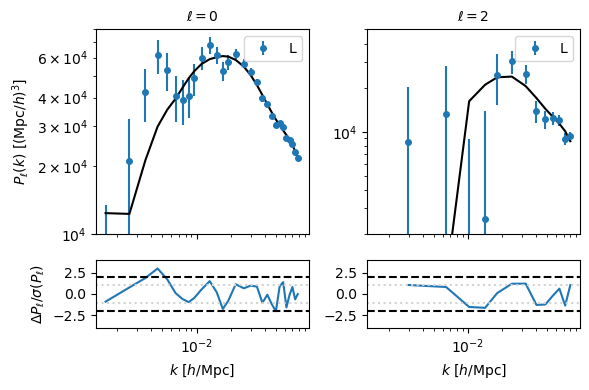

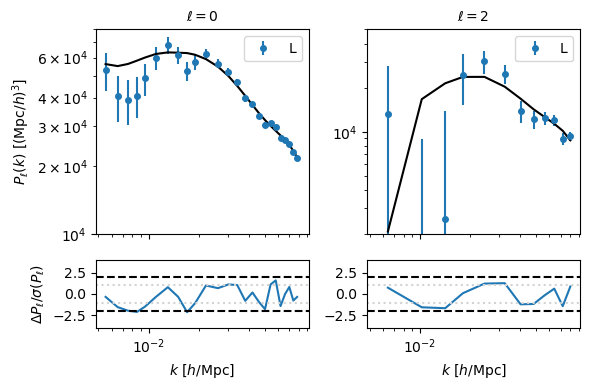

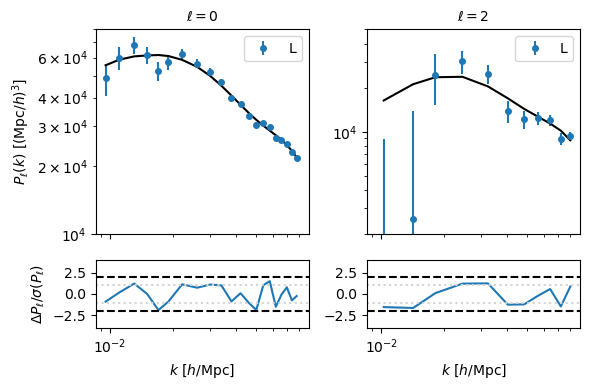

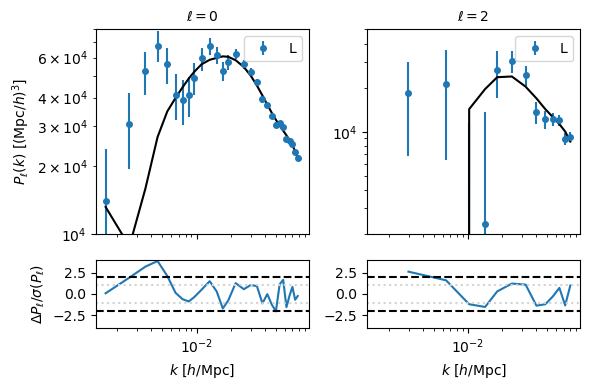

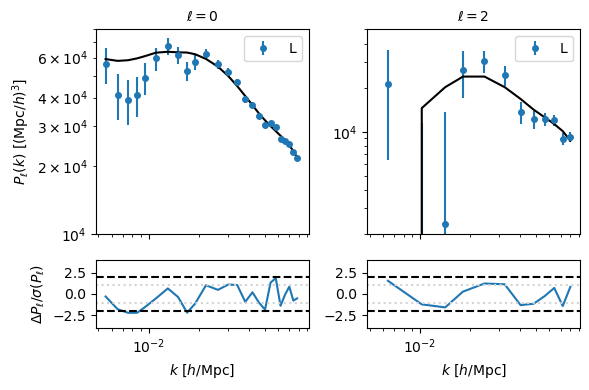

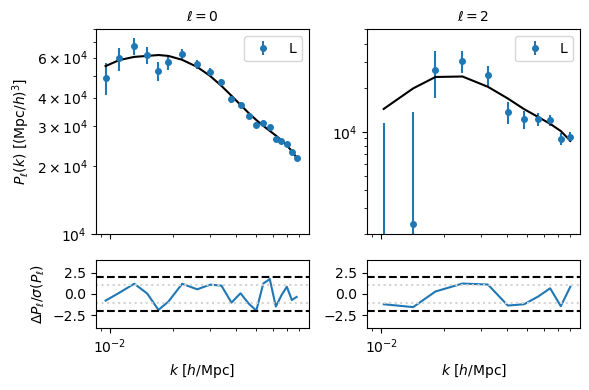

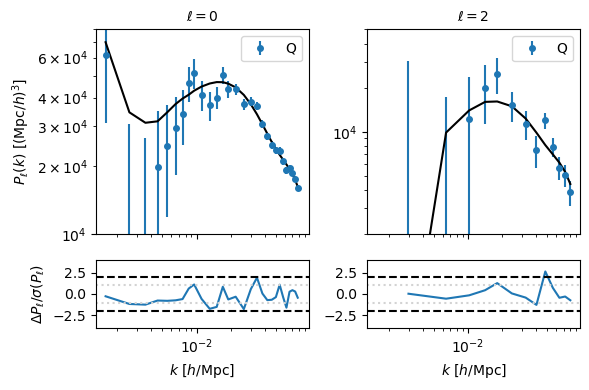

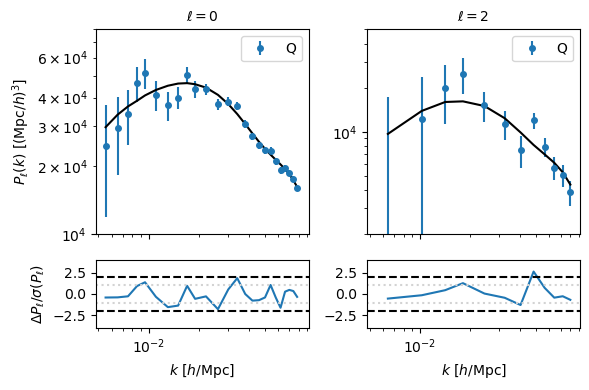

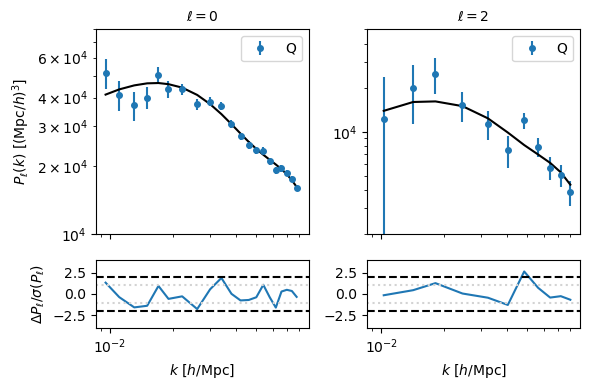

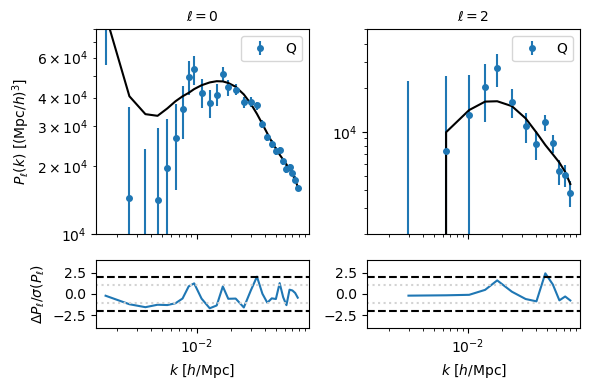

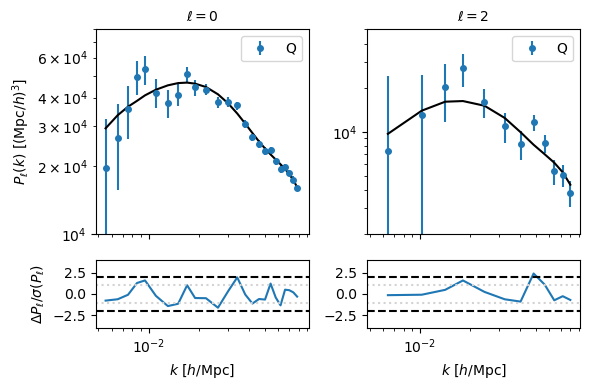

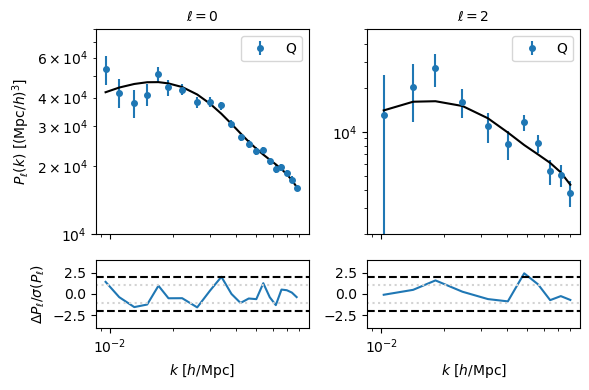

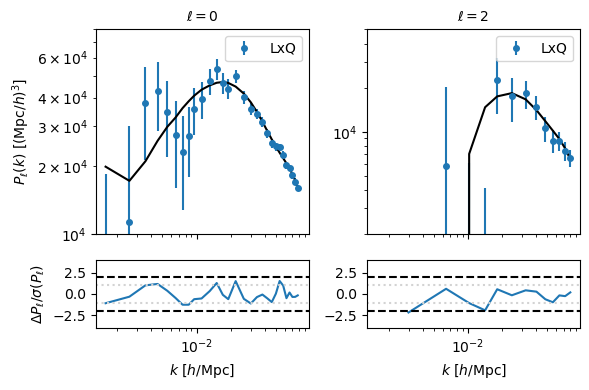

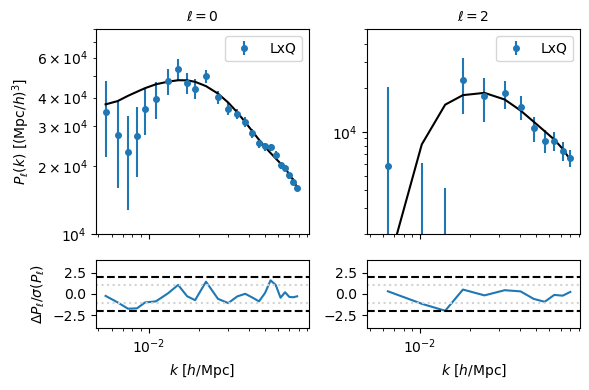

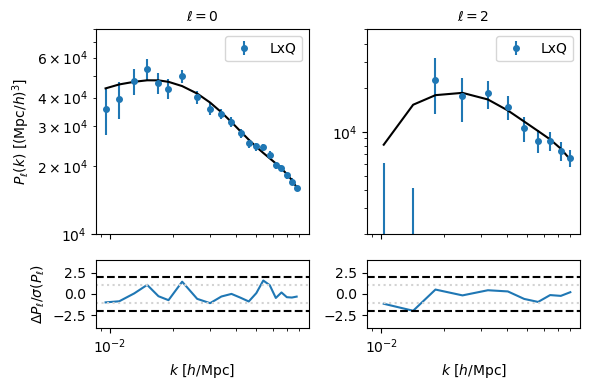

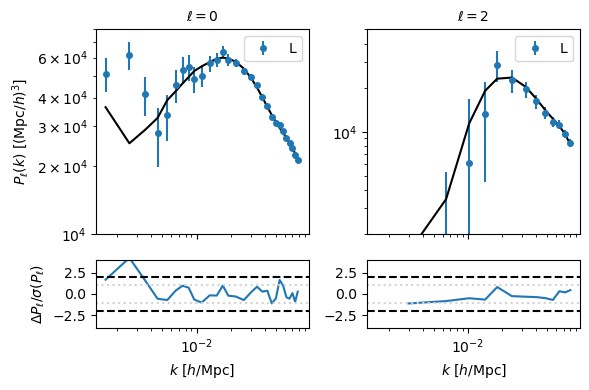

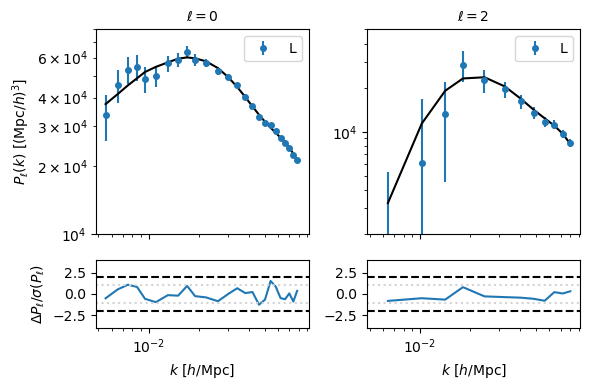

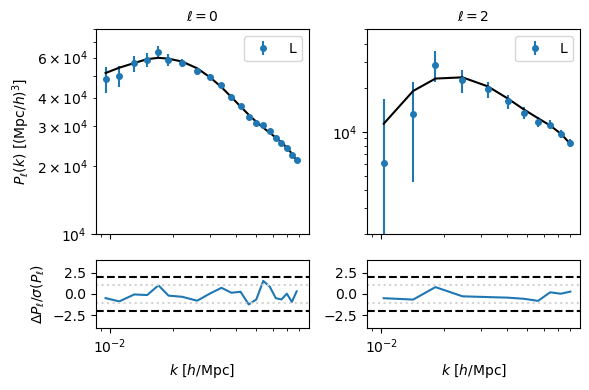

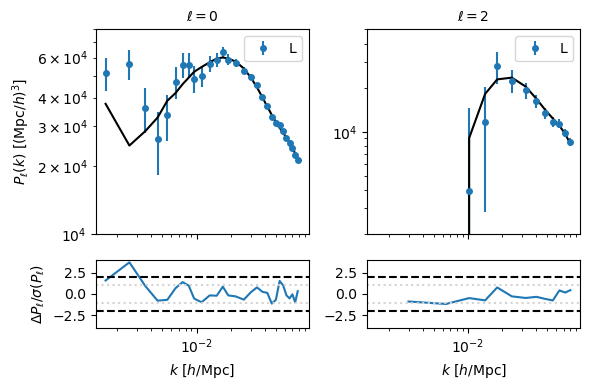

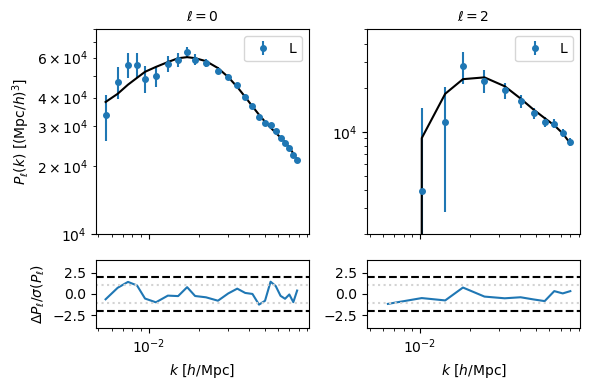

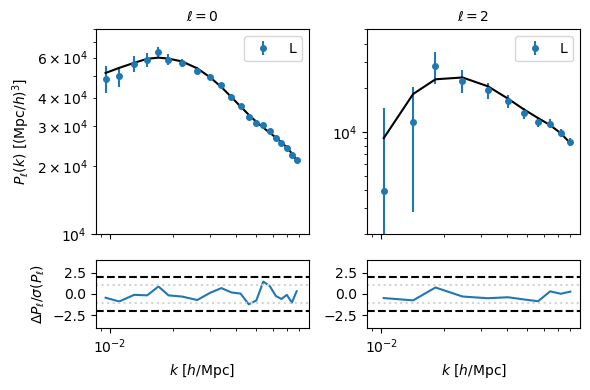

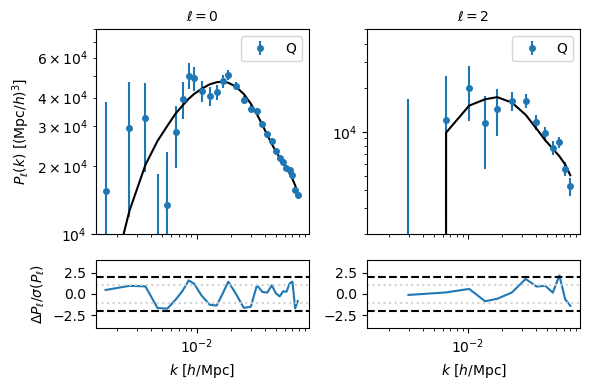

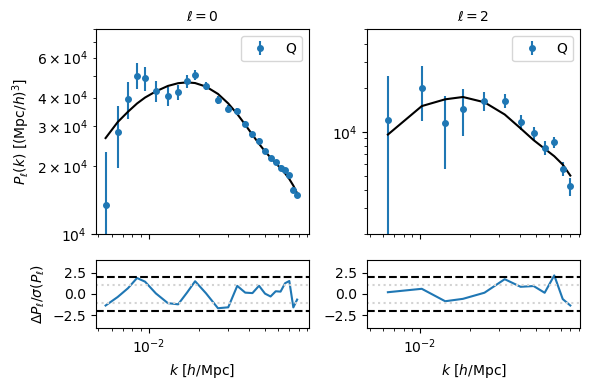

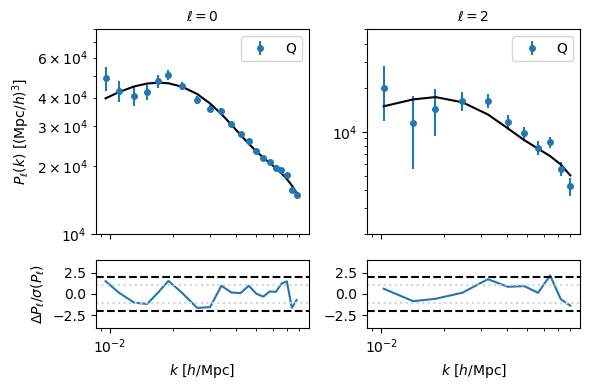

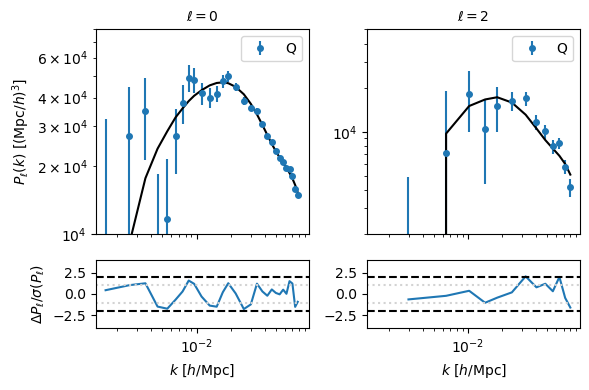

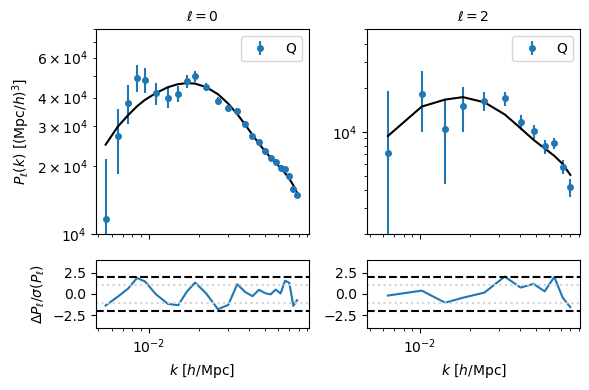

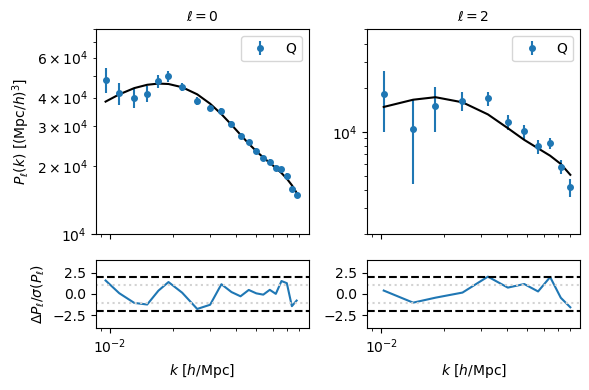

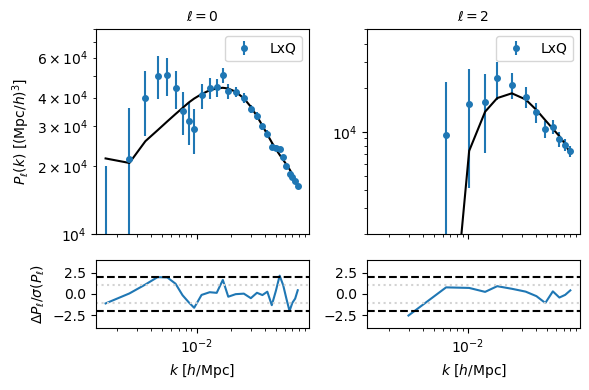

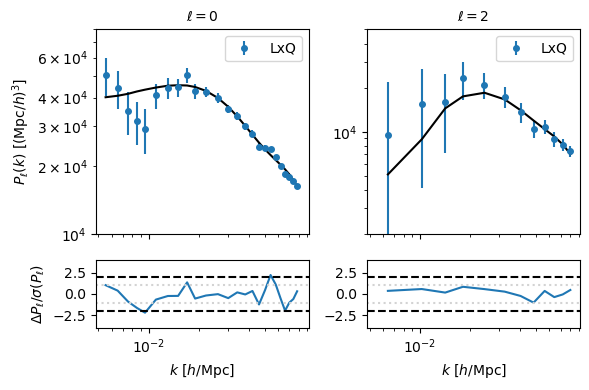

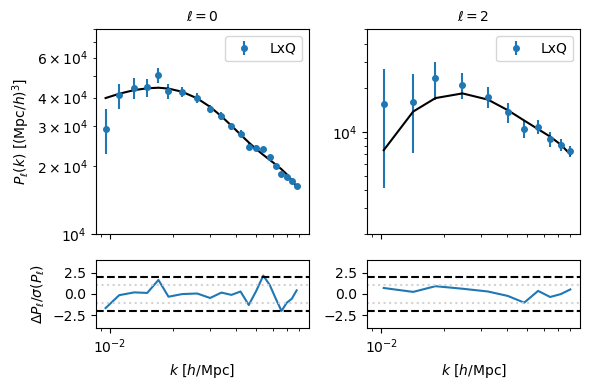

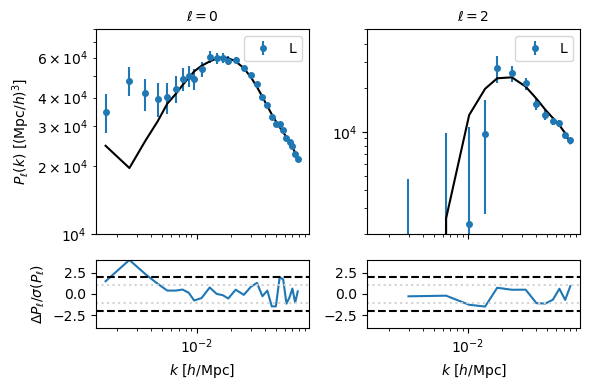

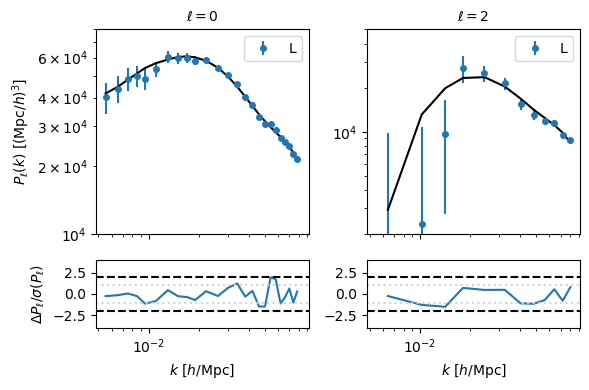

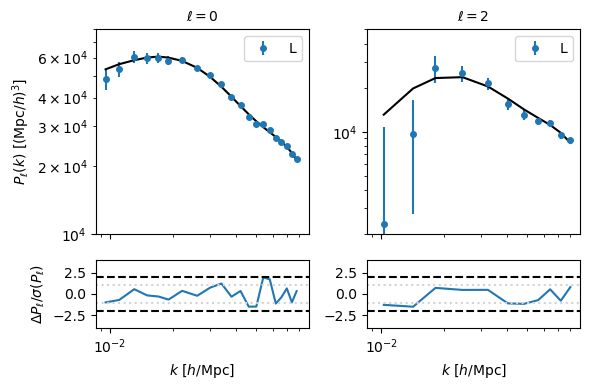

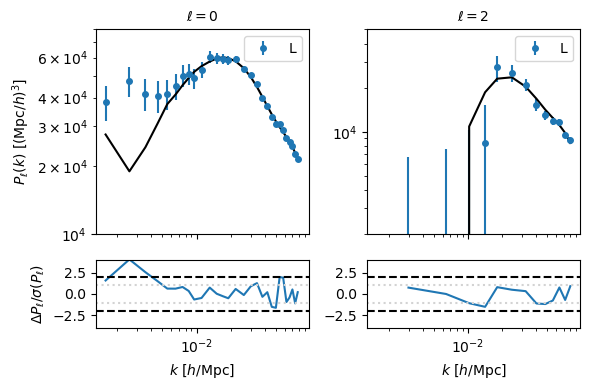

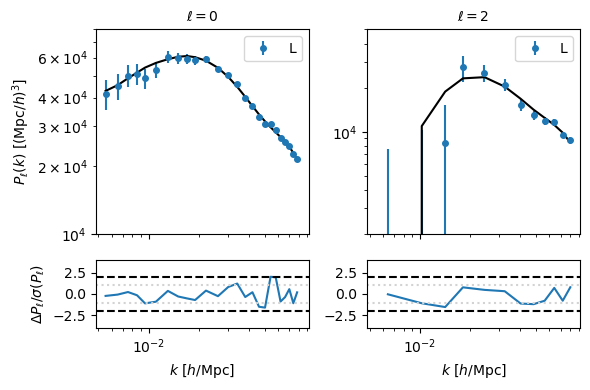

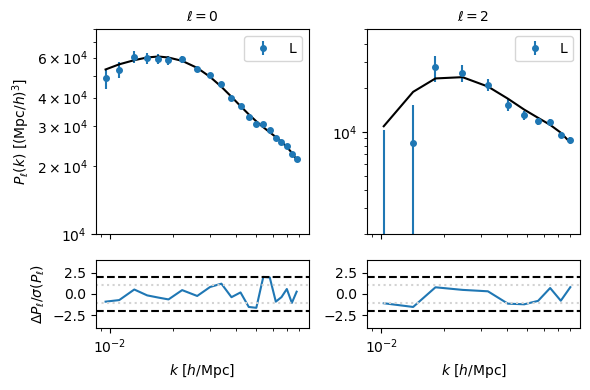

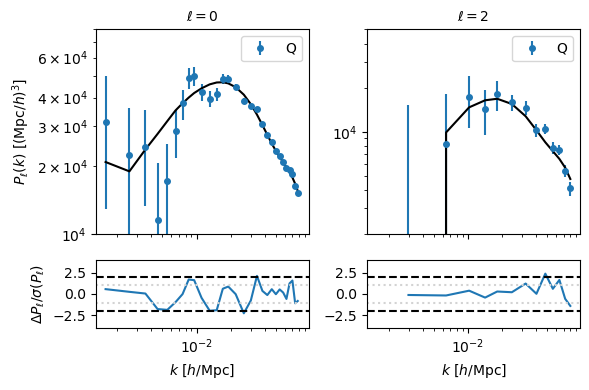

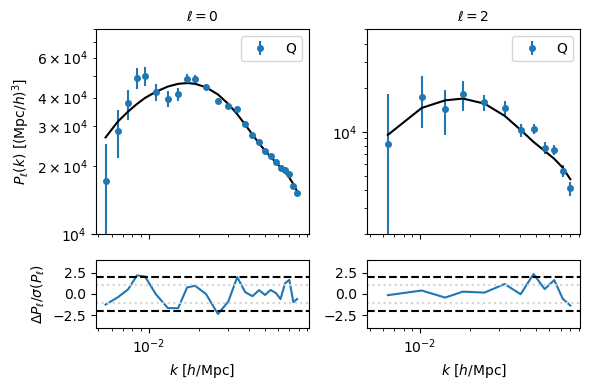

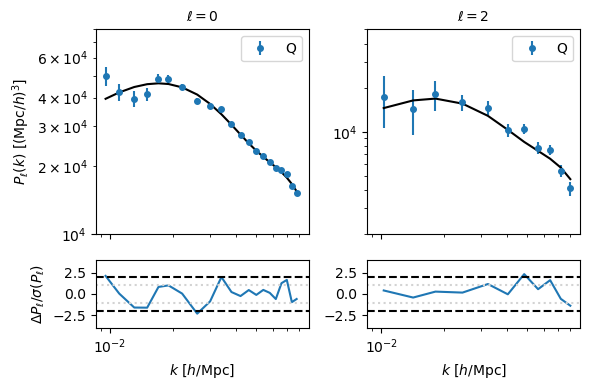

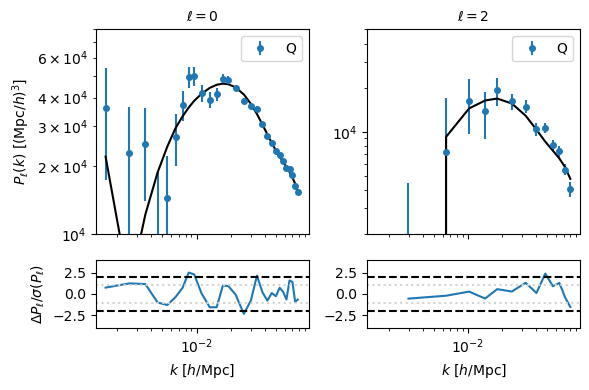

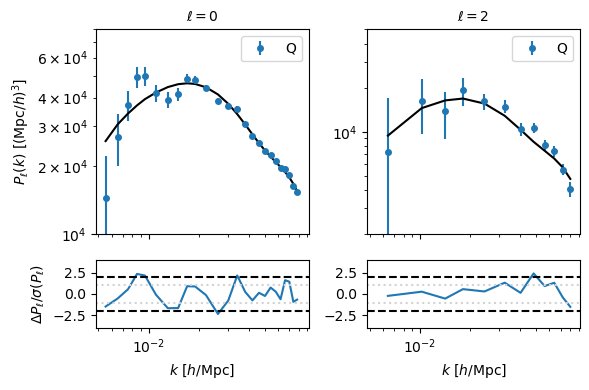

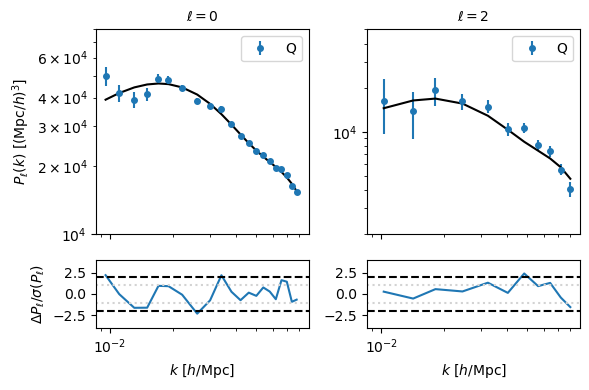

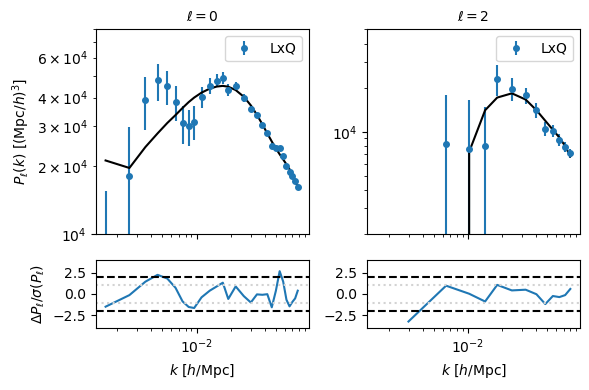

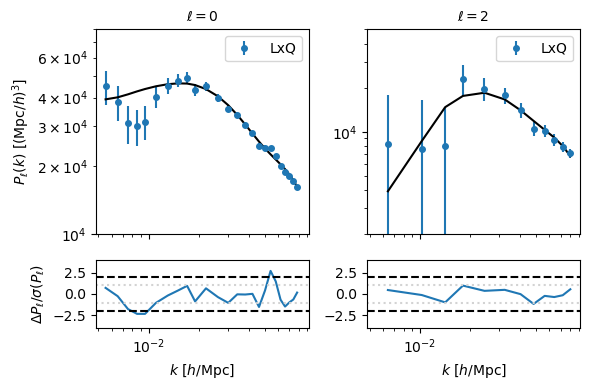

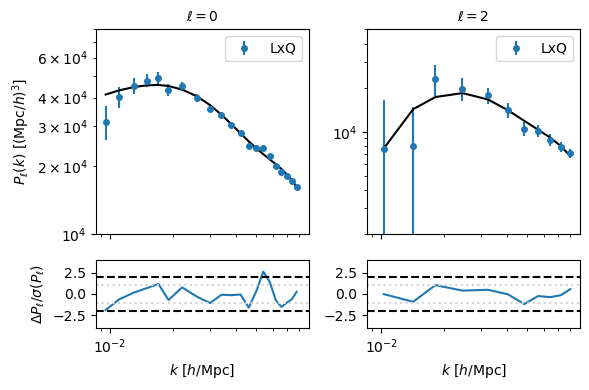

In [6]:
logging.getLogger().setLevel(logging.ERROR)

regions = ['SGC', 'NGC', 'GCcomb']

kmins = [1e-3, 3e-3, 4e-3, 5e-3, 6e-3, 7e-3, 9e-3]

liks, profs = {}, {}
for region in regions:
    for tracer in tracers_to_read:
        short_tracer = tracer.replace('_zcmb', '').replace('notqso', '')

        kwargs = {'scale_covariance': 1}
        if 'x' in short_tracer:
            from clustering_statistics.tools import bias
            tt1 = short_tracer.split('x')[0]
            kwargs[f'{tt1}_{short_tracer}_ell0.b1'] = bias(zeffs[region][short_tracer][0], tracer=tt1)
        #print(kwargs)

        for kmin in kmins:

            pp = pks[region][tracer].select(k=(kmin, 0.2))
            ww = windows[region][tracer].at.observable.match(pp)
            mm = [mock.match(pp) for mock in mocks[region][tracer]]

            obs, liks[(tracer, region, kmin)] = get_observable_and_likelihood(pp, ww, mm, short_tracer, zeffs[region], nickname=short_tracer, engine='camb', **kwargs)
            profs[(tracer, region, kmin)] = run_profiler(liks[(tracer, region, kmin)])

            if kmin in kmins[::3]: plot_observables({short_tracer: obs})

logging.getLogger().setLevel(logging.INFO)

In [7]:
import os


def get_val_err(prof, param, sigfigs=4):
    """Single-param lookup, kept for use elsewhere."""
    val, err = prof.profiles.to_stats(tablefmt='list', sigfigs=sigfigs, params=[param])[0][0][2:]
    return float(val), np.nan if err == '' else float(err)


def get_vals_errs(prof, params, sigfigs=4):
    """Fetch (value, error) for several params in one to_stats() call instead of one per param."""
    rows = prof.profiles.to_stats(tablefmt='list', sigfigs=sigfigs, params=params)[0]
    # assumes rows come back in the same order as `params` -- worth a quick sanity check
    # the first time you run this (e.g. len(rows) == len(params))
    return {p: (float(v), np.nan if e == '' else float(e)) for p, (_, _, v, e) in zip(params, rows)}


def compute_red_chi2s(liks, return_ndof=True):

    red_chi2s = {}
    ndofs = {}

    for key, lik in liks.items():
        chi2_val = lik.flatdiff.dot(lik.precision).dot(lik.flatdiff)
        ndofs[key] = lik.flatdiff.size - len(get_params(lik).select(input=True))
        red_chi2s[key] = chi2_val / ndofs[key]
        #sigma_range = (float(1 - np.sqrt(2/ndofs[key])), float(1 + np.sqrt(2/ndofs[key])))

    if return_ndof:
        return red_chi2s, ndofs
    else:
        return red_chi2s
    

def plot_chi2_diagnostics(tt, liks, regions, kmins, ref_region='GCcomb', outdir='fig_data'):
    os.makedirs(outdir, exist_ok=True)

    fig, ax = plt.subplots(figsize=(4, 2.7))
    for region in regions:
        red_chi2, ndof = compute_red_chi2s({(tt, region, kmin): liks[(tt, region, kmin)] for kmin in kmins})
        if region == ref_region:
            ax.plot(kmins, [red_chi2[(tt, region, kmin)] for kmin in kmins], 'k--', lw=2, label=region, zorder=3)
        else:
            ax.plot(kmins, [red_chi2[(tt, region, kmin)] for kmin in kmins], 'o-', label=region)

    ax.axhline(1, color='k', ls=':')
    ax.fill_between(kmins, 1 - np.sqrt(2/np.array(list(ndof.values()))), 1 + np.sqrt(2/np.array(list(ndof.values()))), color='gray', alpha=0.1)
    ax.set_ylim(0.5, 1.6)
    ax.set_xlabel('kmin')
    ax.set_ylabel('reduced chi2')
    ax.set_title(tt)
    ax.legend(ncol=len(regions))
    fig.tight_layout()
    fig.savefig(f'{outdir}/chi2_{tt}.png', dpi=400)
    plt.show()
    plt.close(fig)


def plot_param_diagnostics(tt, profs, regions, kmins, sigfigs=4,
                            outdir='fig_data', ref_region='GCcomb'):
    os.makedirs(outdir, exist_ok=True)

    tt_clean = tt.replace('_zcmb', '').replace('notqso', '')
    if 'x' in tt_clean:
        t1, t2 = tt_clean.split('x')
        params = ['fnl_loc', f'{t2}_{tt_clean}_ell0.b1',
                  f'{t1}_{tt_clean}_ell0x{t2}_{tt_clean}_ell0.sn0',
                  f'{t2}_{tt_clean}_ell0.sigmas']
    else:
        params = ['fnl_loc', f'{tt_clean}_ell0.b1',f'{tt_clean}_ell0.sn0',  f'{tt_clean}_ell0.sigmas']

    other_regions = [r for r in regions if r != ref_region]
    region_color = {r: f'C{i}' for i, r in enumerate(other_regions)}

    region_stats = {region: [get_vals_errs(profs[(tt, region, kmin)], params, sigfigs=sigfigs)
                              for kmin in kmins]
                     for region in regions}

    fig, axes = plt.subplots(2, len(params), figsize=(10, 4), sharex=True,
                              gridspec_kw=dict(height_ratios=[2, 1]))

    for j, param in enumerate(params):
        ax_top, ax_bot = axes[0, j], axes[1, j]

        ref_vals = np.array([s[param][0] for s in region_stats[ref_region]])
        ref_errs = np.array([s[param][1] for s in region_stats[ref_region]])
        ax_top.plot(kmins, ref_vals, 'k-', lw=1.5, zorder=3)
        ax_top.fill_between(kmins, ref_vals - ref_errs, ref_vals + ref_errs,
                             color='k', alpha=0.15, label=ref_region, zorder=2)

        ax_bot.axhline(0, color='k', ls='--')
        ax_bot.fill_between(kmins, -1, 1, color='gray', alpha=0.1)

        for region in other_regions:
            vals = np.array([s[param][0] for s in region_stats[region]])
            errs = np.array([s[param][1] for s in region_stats[region]])
            ax_top.errorbar(kmins, vals, yerr=errs, ls=':', fmt='o',
                             color=region_color[region], label=region)
            ax_bot.plot(kmins, (vals - ref_vals) / errs, 'o-', color=region_color[region])

        ax_top.set_ylabel(param.split('.')[-1])
        ax_bot.set_ylabel(f'pull vs {ref_region}')
        ax_bot.set_xlabel('kmin')
        ax_bot.set_ylim(-3, 3)

        ax_top.axvline(5e-3, color='gray', ls='--')
        ax_top.axvline(3e-3, color='gray', ls='--')

    axes[0, 0].legend(ncol=1)
    fig.suptitle(tt, y=0.95)
    fig.tight_layout()
    fig.savefig(f'{outdir}/params_{tt}.png', dpi=400)
    plt.show()
    plt.close(fig)

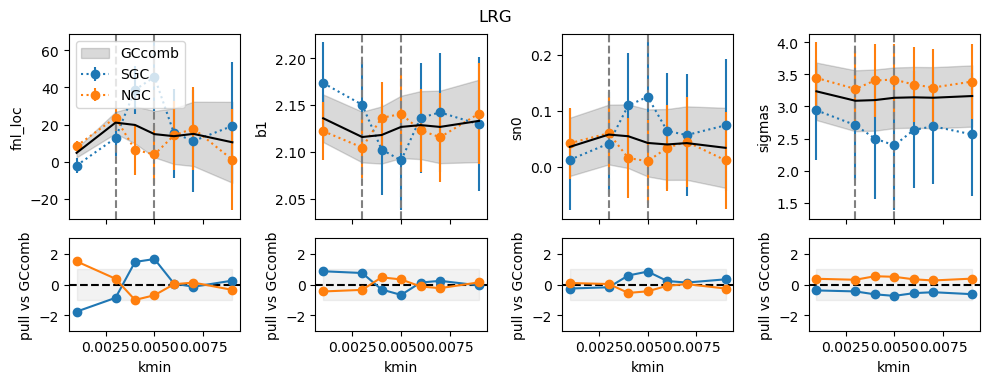

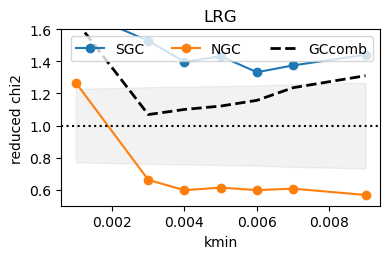

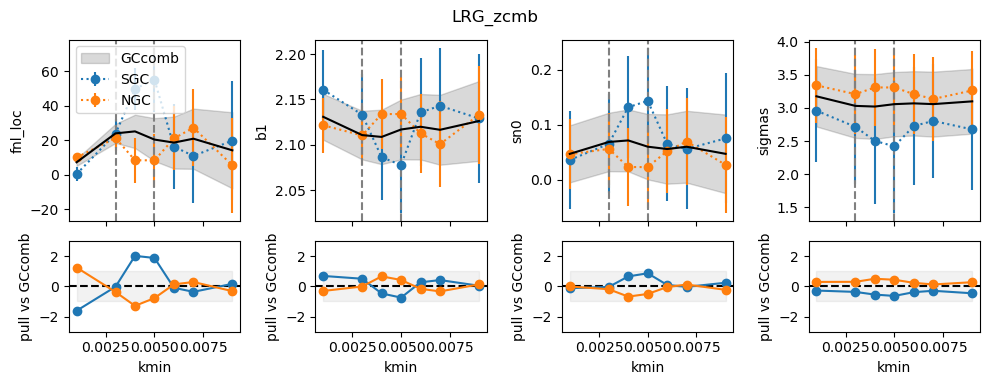

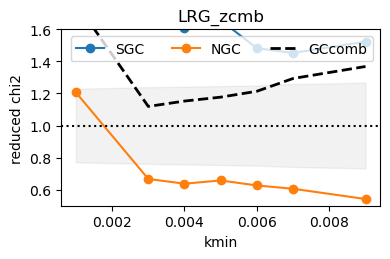

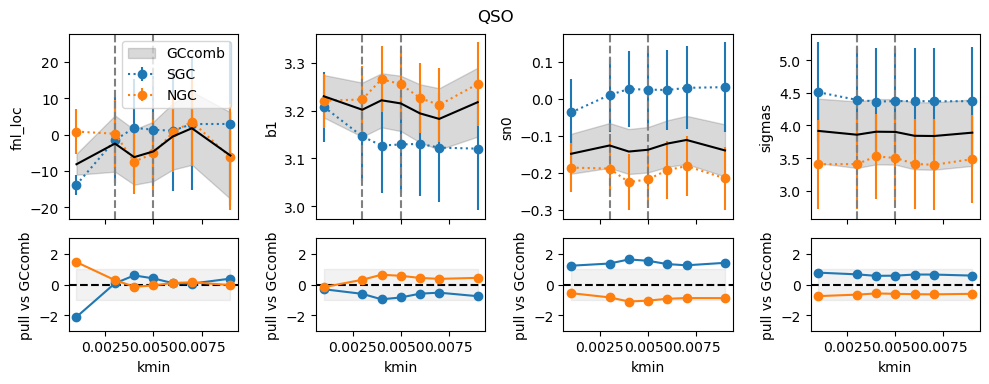

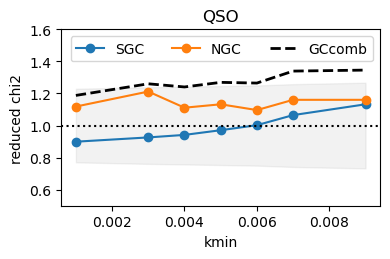

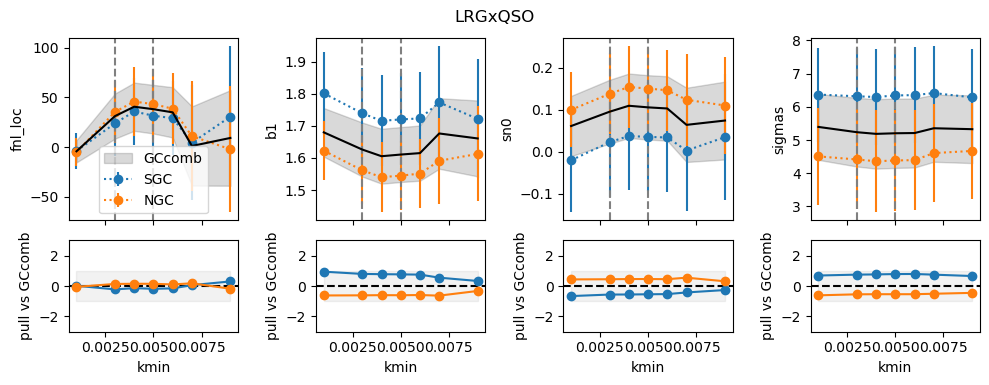

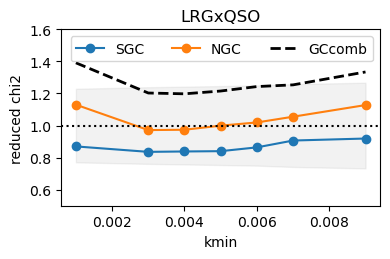

In [9]:
for tt in ['LRG', 'LRG_zcmb', 'QSO', 'LRGxQSO']: #, 'LRGxELGnotqso', 'ELGnotqsoxQSO', 'ELGnotqso']:
#for tt in ['QSO', 'QSO_zcmb']:
    plot_param_diagnostics(tt, profs, regions, kmins)
    plot_chi2_diagnostics(tt, liks, regions, kmins)

# Let's have a deep look to qso:

In [ ]:
from scipy.stats import chi2
pte = chi2.sf(chi2_red * ndof, ndof)

In [87]:
logging.getLogger().setLevel(logging.WARNING)

# just to have a coherent value of b1 in the cross correlation.
kwargs = {'LRG_cross_ell0.b1': 2.15, 'ELG_cross_ell0.b1': 1.2}

regions = ['SGC', 'NGC', 'GCcomb']

#regions = ['NGC']

kmins = [2e-3, 3e-3, 5e-3, 7e-3, 1e-2]

kmax = 0.08

liks = liks if 'liks' in vars() else {}
profs = profs if 'profs' in vars() else {}
for region in regions:
    for tracer in ['QSO']:
        short_tracer = tracer.replace('_zcmb', '').replace('notqso', '')

        for kmin in kmins:

            pp = pks[region][tracer].select(k=(kmin, kmax))
            ww = windows[region][tracer].at.observable.match(pp)
            mm = [mock.match(pp) for mock in mocks[region][tracer]]

            obs, liks[(tracer, region, kmin)] = get_observable_and_likelihood(pp, ww, mm, short_tracer, zeffs[region], 
                                                                              fix_fnl=False, nickname=short_tracer, engine='camb', **kwargs)
            profs[(tracer, region, kmin)] = run_profiler(liks[(tracer, region, kmin)])
            #print(region, kmin, profs[(tracer, region, kmin)].profiles.to_stats(tablefmt="pretty"))
            #if kmin in kmins[::2]: plot_observables({short_tracer: obs})

logging.getLogger().setLevel(logging.INFO)

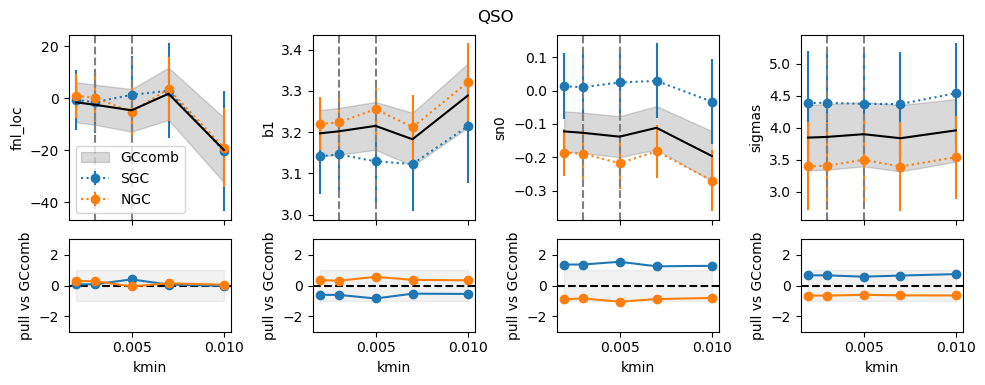

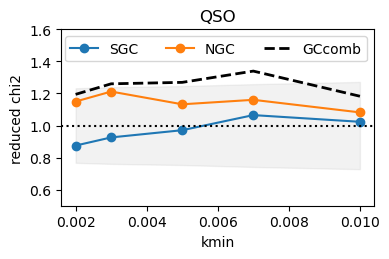

In [88]:
plot_param_diagnostics('QSO', profs, regions, kmins)
plot_chi2_diagnostics('QSO', liks, regions, kmins)

0.43411527685667295 0.11636677754935379


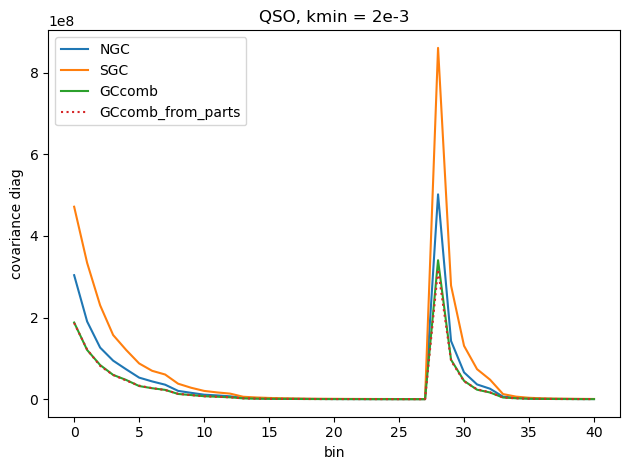

In [14]:
factor_NGC = (pks['NGC']['QSO'].get(0).norm**2 / (pks['NGC']['QSO'].get(0).norm + pks['SGC']['QSO'].get(0).norm)**2)[0]
factor_SGC = (pks['SGC']['QSO'].get(0).norm**2 / (pks['NGC']['QSO'].get(0).norm + pks['SGC']['QSO'].get(0).norm)**2)[0]

print(factor_NGC, factor_SGC)

diag_NGC = np.diag(liks[('QSO', 'NGC', 2e-3)].covariance.value())
diag_SGC = np.diag(liks[('QSO', 'SGC', 2e-3)].covariance.value())
diag_GCcomb = np.diag(liks[('QSO', 'GCcomb', 2e-3)].covariance.value())
diag_GCcomb_from_parts = factor_NGC * diag_NGC + factor_SGC * diag_SGC

plt.plot(diag_NGC, label='NGC')
plt.plot(diag_SGC, label='SGC')
plt.plot(diag_GCcomb, label='GCcomb')
plt.plot(diag_GCcomb_from_parts, ls=':', label='GCcomb_from_parts')

plt.legend()
plt.xlabel('bin')
plt.ylabel('covariance diag')
plt.title('QSO, kmin = 2e-3')
plt.tight_layout()
plt.show()

In [89]:
tracer = 'QSO'

chains = chains if 'chains' in vars() else {}
for region in ['NGC', 'SGC', 'GCcomb']:
    for kmin in [7e-3]:
        chains[(tracer, region, kmin)] = run_mcmc(liks[(tracer, region, kmin)])

[006763.25] [0/1] 06-19 17:39  EmceeSampler              INFO     Varied parameters: ['fnl_loc', 'QSO_ell0.sn0', 'QSO_ell0.b1', 'QSO_ell0.sigmas'].
[None]
[006763.38] [0/1] 06-19 17:39  EmceeSampler              INFO     Successfully vmap input likelihood.
[006763.58] [0/1] 06-19 17:39  EmceeSampler              INFO     Successfully jit input likelihood.


100%|██████████| 5000/5000 [00:20<00:00, 244.66it/s]

[006784.74] [0/1] 06-19 17:40  Chain                     INFO     Saving tmp/mcmc_output_0.npy.



100%|██████████| 5000/5000 [00:17<00:00, 282.45it/s]

[006802.47] [0/1] 06-19 17:40  Chain                     INFO     Saving tmp/mcmc_output_0.npy.


...

[006940.65] [0/1] 06-19 17:42  Chain                     INFO     Saving tmp/mcmc_output_0.npy.



100%|██████████| 5000/5000 [00:15<00:00, 320.07it/s]

[006956.31] [0/1] 06-19 17:42  Chain                     INFO     Saving tmp/mcmc_output_0.npy.



100%|██████████| 5000/5000 [00:15<00:00, 320.23it/s]

[006971.97] [0/1] 06-19 17:43  Chain                     INFO     Saving tmp/mcmc_output_0.npy.


0 0 fnl_loc QSO_ell0.sigmas 0
0 1 fnl_loc QSO_ell0.sn0 1
0 2 fnl_loc QSO_ell0.b1 2
1 0 QSO_ell0.b1 QSO_ell0.sigmas 3
1 1 QSO_ell0.b1 QSO_ell0.sn0 4
2 0 QSO_ell0.sn0 QSO_ell0.sigmas 6


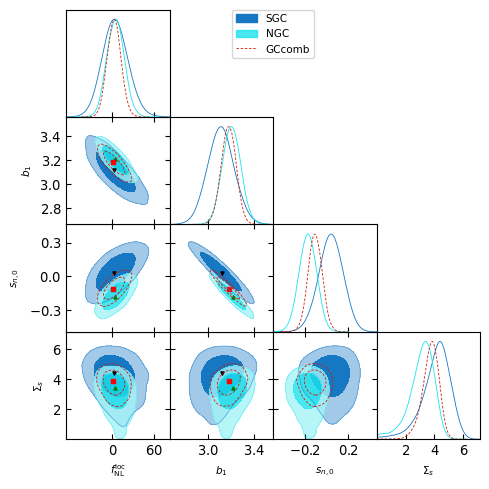

In [91]:
from desilike.samples import MCSamples
from tools import get_getdist_plotter, plot_triangle

import getdist.chains
getdist.chains.print_load_details = False

burnin, thin = 0.3, 10

kmin = 7e-3

to_display = []
for region in ['SGC', 'NGC', 'GCcomb']:
    to_display += [MCSamples.concatenate([cc.remove_burnin(burnin)[::thin] for cc in chains[('QSO', region, kmin)].chains])]


g = get_getdist_plotter(fig_width_inch=5)

legend_labels = [f'{region}' for region in ['SGC', 'NGC', 'GCcomb']]
params = ['fnl_loc', 'QSO_ell0.b1', 'QSO_ell0.sn0', 'QSO_ell0.sigmas']

fig = plot_triangle(to_display,  params, legend_labels=legend_labels, 
                    xlabels=[r'$f_{\rm NL}^{\rm loc}$', r'$b_1$', r'$s_{n,0}$', r'$\Sigma_{s}$'], 
                    contour_colors=["#1677c2", "#1be3ed", "#cd1b07", '#98df8a', '#ffbb78', '#aec7e8',],
                    filled=[True, True, False, True, True, True],
                    contour_ls=['-', '-', '--', '--', '--', '--'],  g=g, return_fig=True)

axs = fig.get_axes()

bestfit_sgc = [profs[('QSO', 'SGC', kmin)].profiles.choice(index='argmax', squeeze=True).best[nn] for nn in params]
bestfit_ngc = [profs[('QSO', 'NGC', kmin)].profiles.choice(index='argmax', squeeze=True).best[nn] for nn in params]
bestfit_gccomb = [profs[('QSO', 'GCcomb', kmin)].profiles.choice(index='argmax', squeeze=True).best[nn] for nn in params]

for i in range(len(params)):
    for j in range(len(params) - 1- i):
        print(i, j, params[i], params[len(params) - 1 - j], i * (len(params) - 1) + j)
        axs[i * (len(params)) + j].scatter(bestfit_sgc[i], bestfit_sgc[len(params)-1-j], marker='v', s=5, c='k')
        axs[i * (len(params)) + j].scatter(bestfit_ngc[i], bestfit_ngc[len(params)-1-j], marker='^', s=5, c='g')
        axs[i * (len(params)) + j].scatter(bestfit_gccomb[i], bestfit_gccomb[len(params)-1-j], marker='s', s=5, c='r')

#axs[2].axhline(2.151, ls='--', c='k', lw=1)
#axs[3].set_title(f'{tracer_save} Mocks {key}')
#plt.savefig(f'fig/{tracer_save}_mocks_mcmc_test{key}_{ii}.png', dpi=400)
plt.show()


In [51]:
def load_all_profiles(mocks_dir):
    # TODO: FIXME, use .h5
    """
    Load all profile .npy files from the holi-v3-altmtl/mock* directories
    and organize them in a nested dictionary structure.
    
    Handles filenames with optional suffixes:
    - bestfit_{tracer}_{region}_{cov_type}_kmin-{kmin}.h5
    - bestfit_{tracer}_{region}_{cov_type}_kmin-{kmin}_{any_suffix}.h5
    
    Returns:
        profiles: dict with structure {tracer: {region: {cov_type: {kmin: {suffix: {imock: array}}}}}}
    """
    import re
    from pathlib import Path
    from collections import defaultdict

    base_dir = Path(mocks_dir.replace('summary_statistics', 'profiles')) / 'holi-v3-altmtl'
    
    profiles = defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(dict)))))
    
    pattern = r'bestfit_(.+?)_((?:NGC|SGC|GCcomb))_(analytical_cov|mock_cov)_kmin-([0-9e\-\.]+)(_.*)?\.npy'
    
    mock_dirs = sorted(base_dir.glob('mock*'), key=lambda x: int(x.name.replace('mock', '')))
    
    for mock_dir in mock_dirs:
        if not mock_dir.is_dir():
            continue
        
        imock = int(mock_dir.name.replace('mock', ''))
        
        for npy_file in sorted(mock_dir.glob('bestfit_*.npy')):
            match = re.match(pattern, npy_file.name)
            if match:
                tracer, region, cov_type, kmin, suffix = match.groups()
                kmin = float(kmin)
                suffix = suffix if suffix else ''
                
                profiles[tracer][region][cov_type][kmin][suffix][imock] = np.load(str(npy_file))
    
    profiles = {k: {k2: {k3: {k4: {k5: dict(v5) for k5, v5 in v4.items()} for k4, v4 in v3.items()} for k3, v3 in v2.items()} for k2, v2 in v.items()} 
                for k, v in profiles.items()}
    
    return profiles

# Where the mocks are:
mocks_dir = root + 'dr2/summary_statistics/local_png/base/'

# Load all the available profiles into a nested dictionary for easy access:
profiles = load_all_profiles(mocks_dir)

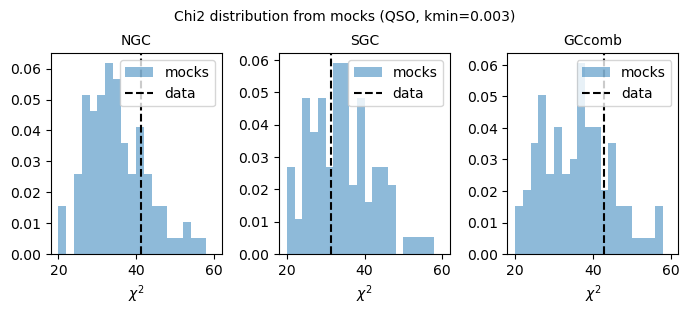

In [108]:
nparams = 4
kmin = 0.003

chi2_ngc = [-2*float(profiles['QSOxQSO']['NGC']['mock_cov'][kmin]['_RIC+AMR'][i][nparams][-2]) for i in range(100)]
chi2_sgc = [-2*float(profiles['QSOxQSO']['SGC']['mock_cov'][kmin]['_RIC+AMR'][i][nparams][-2]) for i in range(100)]
chi2_gccomb = [-2*float(profiles['QSOxQSO']['GCcomb']['mock_cov'][kmin]['_RIC+AMR'][i][nparams][-2]) for i in range(100)]

chi2_data_ngc = -2*float(profs[('QSO', 'NGC', kmin)].profiles.bestfit.choice()['logposterior'])
chi2_data_sgc = -2*float(profs[('QSO', 'SGC', kmin)].profiles.bestfit.choice()['logposterior'])
chi2_data_gccomb = -2*float(profs[('QSO', 'GCcomb', kmin)].profiles.bestfit.choice()['logposterior'])

plt.figure(figsize=(7, 3.3))
plt.subplot(131)
plt.hist(chi2_ngc, bins=20, range=(20, 60), alpha=0.5, label='mocks', density=True)
plt.axvline(chi2_data_ngc, color='k', ls='--', label='data')
plt.legend()
plt.title('NGC', fontsize=10)
plt.xlabel(r'$\chi^2$')
plt.subplot(132)
plt.hist(chi2_sgc, bins=20, range=(20, 60), alpha=0.5, label='mocks', density=True)
plt.axvline(chi2_data_sgc, color='k', ls='--', label='data')
plt.legend()
plt.title('SGC', fontsize=10)
plt.xlabel(r'$\chi^2$')
plt.subplot(133)
plt.hist(chi2_gccomb, bins=20, range=(20, 60), alpha=0.5, label='mocks', density=True)
plt.axvline(chi2_data_gccomb, color='k', ls='--', label='data')
plt.legend()
plt.title('GCcomb', fontsize=10)
plt.xlabel(r'$\chi^2$')
plt.suptitle('Chi2 distribution from mocks (QSO, kmin=0.003)', y=0.94, fontsize=10)

plt.tight_layout()
#plt.savefig('fig_data/chi2_distribution_mocks_QSOxQSO_kmin_0.003.png', dpi=400)
plt.show()  

In [111]:
profs[('QSO', 'NGC', 7e-3)].profiles.choice(index='argmax', squeeze=True).best

{'fnl_loc': ParameterArray(fnl_loc, None, 3.5829632233484343),
 'QSO_ell0.sn0': ParameterArray(QSO_ell0.sn0, None, -0.18238633844258428),
 'QSO_ell0.b1': ParameterArray(QSO_ell0.b1, None, 3.2119125632932817),
 'QSO_ell0.sigmas': ParameterArray(QSO_ell0.sigmas, None, 3.3952601353198664),
 'logposterior': ParameterArray(logposterior, None, -16.9678894001696),
 'QSO_ell2.sn0': ParameterArray(QSO_ell2.sn0, None, 0.0),
 'QSO_ell2.p': ParameterArray(QSO_ell2.p, None, 1.4),
 'QSO_ell0.p': ParameterArray(QSO_ell0.p, None, 1.4),
 'QSO_ell2.b1': ParameterArray(QSO_ell2.b1, None, 3.0231051990941884),
 'QSO_ell2.sigmas': ParameterArray(QSO_ell2.sigmas, None, 3.3952601353198664),
 'loglikelihood': ParameterArray(loglikelihood, None, -16.967889383537205),
 'logprior': ParameterArray(logprior, None, -1.6632388225246447e-08)}

In [124]:
print(MCSamples.concatenate(chains[('QSO', 'NGC', 7e-3)].chains).remove_burnin(0.3)[::10].to_stats(tablefmt='pretty', sigfigs=4))

# test = [float(profiles['QSOxQSO']['NGC']['mock_cov'][7e-3]['_RIC+AMR'][i][0][-2]) for i in range(100)]
# or the from the mcmc over the mean of 50? 

+-----------------+----------+----------+----------+---------+-------------------+-------------------+
|                 |  argmax  |   mean   |  median  |   std   |  quantile:1sigma  |  interval:1sigma  |
+-----------------+----------+----------+----------+---------+-------------------+-------------------+
|     fnl_loc     |   4.39   |   4.91   |   4.82   |  12.72  |   -12.94/+12.72   |   -12.66/+12.89   |
|  QSO_ell0.sn0   | -0.17516 | -0.17523 | -0.17457 | 0.08169 | -0.08211/+0.08278 | -0.08519/+0.07903 |
|   QSO_ell0.b1   | 3.20556  | 3.20151  | 3.20073  | 0.08005 | -0.08047/+0.08027 | -0.07853/+0.08186 |
| QSO_ell0.sigmas |  3.3136  |  3.1070  |  3.2211  | 0.8819  |  -0.8129/+0.8313  |  -0.6044/+0.9771  |
|   QSO_ell2.b1   | 3.01713  | 3.01331  | 3.01258  | 0.07534 | -0.07574/+0.07555 | -0.07392/+0.07705 |
| QSO_ell2.sigmas |  3.3136  |  3.1070  |  3.2211  | 0.8819  |  -0.8129/+0.8313  |  -0.6044/+0.9771  |
+-----------------+----------+----------+----------+---------+-----------

[ 5787.32748924  4825.24177508 -1711.14119547 -1995.96008407
   -14.89132483  2706.40449379   791.72129939 -1800.79893245
  -270.31196186    72.37589686  -356.34428822   -21.39429945
  -308.9373216   -130.1817767    179.40170702  -564.1623647
  -646.84572712   288.57779023   138.57920772]
23.31056516359036


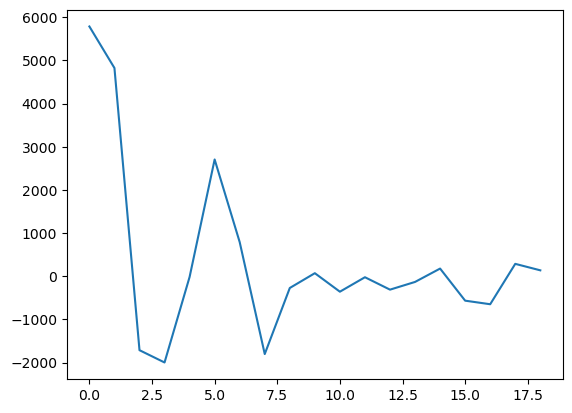

In [ ]:
# FIXME: desilike implements hartlap only

print(lik.correct_covariance)

# precision (ie) inverse of the covariance with only hartlap correction, no Percival factor.
print(lik.precision_hartlap2007)
# here the percival factor: 
print(lik.percival2014_factor)
# here the final precision used in the likelihood, with both hartlap and percival correction:
print(lik.precision)

params = {'fnl_loc': 0, 'QSO_ell0.b1': 3.19, 'QSO_ell0.sigmas': 4, 'QSO_ell0.sn0': -0.12}
lik(**params)
print(lik.flatdiff)

print(chi2(lik.flatdiff, lik.precision))

plt.plot(lik.flatdiff)

In [ ]:
#orders = [['LRGxLRG', 'QSOxQSO', 'LRGxQSO']]
orders = [['LRGxLRG', 'QSOxQSO', 'LRGxQSO', 'LRGxELG', 'ELGxQSO']]
orders += [['LRGxLRG', 'QSOxQSO', 'ELGxELG', 'LRGxQSO', 'LRGxELG', 'ELGxQSO']]

for order in orders:

    obs = {tracer: get_observable_and_likelihood(pks[tracer], windows[tracer], covs if analytical_covariance else mocks[tracer], 
                                                 tracer, zeffs, nickname=tracer, drop_ell2_cross=True, engine='camb', **kwargs)[-1] for tracer in order}

    likelihoods['-'.join(order)] = build_total_likelihood(order, pks, obs, covs if analytical_covariance else mocks, zeffs, fiducial)

    profilers['-'.join(order)] = run_profiler(likelihoods['-'.join(order)])
    plot_observables({tracer: obs[tracer] for tracer in order})